# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hassanqureshi46278-art/flyrank-Internship-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [19]:
# Sanity check only — real data loading happens in Section 2.
print("Lane: Content refresh priority (scoring/ranking)")
print("Target/proxy: avg_clicks_28d")

Lane: Content refresh priority (scoring/ranking)
Target/proxy: avg_clicks_28d


## 1. Question

*The research question and the decision it supports.*

A content or SEO team cannot manually review every page in a growing portfolio every sprint. **The question:** out of a large pool of candidate pages, which ones should a content team review first this sprint — and why does a simple fixed rule fall short?

**Unit of analysis:** one page (`content_key`), aggregated over one mid-panel month.

**Output:** a continuous priority score per page, ranked into a queue — not a binary label, since the real decision is who goes to the top of a capacity-limited list.

**Decision it supports:** which pages a content strategist reworks (content update, refreshed metadata, added sections) next sprint.

**Cost of a wrong call:** a false positive wastes writer hours on a fine page; a false negative lets a quietly decaying page keep losing traffic for another cycle before anyone notices. Writer time, not model accuracy, is the scarce resource here.

**Why ML helps:** a fixed if-statement rule treats staleness, demand, and position as independent and equally weighted; in practice they interact — a slightly-stale page with huge demand may matter more than a very stale page nobody searches for. A learned model can pick up that interaction instead of relying on a few hand-tuned thresholds.

**Case study framing:** this project is a direct, smaller-scale test of FlyRank's own portfolio research finding that refreshing older, still-visible pages produces the clearest measured lift available to a content team. Rather than treating that finding as a general truth, we operationalize it into a page-level scoring system a real content team could run every sprint, and honestly report where it agrees and disagrees with a simple hand-written rule.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [20]:
import duckdb
from google.colab import userdata
import pandas as pd
import numpy as np
import os # Import os for environment variable access

con = duckdb.connect()

# Attempt to get HF_TOKEN from Colab secrets, with a fallback to environment variables
try:
    hf_token = userdata.get('HF_TOKEN')
except Exception as e:
    print(f"Warning: Could not retrieve HF_TOKEN from Colab secrets: {e}")
    print("Attempting to retrieve from environment variables.")
    hf_token = os.environ.get('HF_TOKEN')
    if hf_token is None:
        raise ValueError("HF_TOKEN not found in Colab secrets or environment variables. Please set it.")

con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"

raw = con.sql(f"""
    SELECT content_hash_id, client_hash_id, report_date, gsc_clicks, gsc_impressions, gsc_avg_position
    FROM read_parquet('{REL}/fact_content_daily_performance/month={MONTH}/*.parquet')
""").df()

print(f"Rows: {len(raw):,} | Distinct pages: {raw['content_hash_id'].nunique():,} | "
      f"Distinct clients: {raw['client_hash_id'].nunique():,}")
print(f"Date span: {raw['report_date'].min()} to {raw['report_date'].max()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 9,841,378 | Distinct pages: 331,437 | Distinct clients: 55
Date span: 2026-03-01 00:00:00 to 2026-03-31 00:00:00


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** `FlyRank/internship-warehouse` on Hugging Face — an anonymized, star-schema export of Google Search Console and GA4 data with salted, fingerprinted hash keys.

**Table and window:** `fact_content_daily_performance`, filtered to `month=2026-03` (a mid-panel month). The dataset's final month (June 2026, exposed as `_sample`) is deliberately sealed — never touched during feature or label development, since it is the natural outcome window for any past-to-future label.

**Deliberately excluded, and why:**

| Excluded | Reason |
|---|---|
| `fact_content_query_90d` (query-level table) | Adds a join over salted, rare-tail-aggregated hashes with no benefit to a page-level score; widens the leakage surface. |
| `dim_clients` fields beyond `gsc_data_start`/`ga4_data_start` | Anonymization terms restrict use of other client dimension fields. |
| `_sample` table (June 2026) | Sealed as held-out; never used to build features or tune the model. |
| `ctr_28d` (engineered, later dropped) | Derived directly from the target column — confirmed leaky in Section 3. |
| `trend_direction`, `trend_pct` (if present) | Label-derived — describe the outcome the model anticipates, not an input knowable beforehand. |

**Public-safety confirmation:** no client names, page URLs, or raw query text appear anywhere in this notebook — every identifier is the dataset's own salted hash key.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [21]:
feat = raw.groupby(["content_hash_id", "client_hash_id"]).agg(
    avg_clicks_28d=("gsc_clicks", "mean"),
    avg_impressions_28d=("gsc_impressions", "mean"),
    avg_position_28d=("gsc_avg_position", "mean"),
    days_active_in_month=("report_date", "nunique"),
).reset_index()

# Calculate 'days_since_update' as a proxy using the last 'report_date'
last_report_date_agg = raw.groupby("content_hash_id")["report_date"].max().reset_index()
last_report_date_agg.rename(columns={'report_date': 'last_observed_report_date'}, inplace=True) # Rename for clarity
feat = feat.merge(last_report_date_agg, on="content_hash_id", how="left")

feat["days_since_update"] = (pd.Timestamp(f"{MONTH}-01") - pd.to_datetime(feat["last_observed_report_date"])).dt.days
feat["days_since_update"] = feat["days_since_update"].fillna(feat["days_since_update"].median())

final_features = ["avg_impressions_28d", "avg_position_28d", "days_since_update", "days_active_in_month"]
print("Final feature set:", final_features)

# --- Leakage audit ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

target_col = "avg_clicks_28d"

def quick_score(df, feature_cols, target_col):
    data = df.dropna(subset=feature_cols + [target_col])
    X, y = data[feature_cols], data[target_col]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression().fit(Xtr, ytr)
    return r2_score(yte, model.predict(Xte))

baseline_r2 = quick_score(feat, final_features, target_col)
print(f"R2 with final (non-leaky) feature set: {baseline_r2:.3f}")

leak_month = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_clicks) AS next_month_clicks
    FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')
    GROUP BY content_hash_id
""").df()
feat_leak_test = feat.merge(leak_month, on="content_hash_id", how="left")
leaky_r2 = quick_score(feat_leak_test, final_features + ["next_month_clicks"], target_col)
print(f"R2 WITH planted future-month leak: {leaky_r2:.3f}  <-- should jump toward 1.0")
print("ctr_28d and next_month_clicks are excluded from the final feature set used below.")

Final feature set: ['avg_impressions_28d', 'avg_position_28d', 'days_since_update', 'days_active_in_month']
R2 with final (non-leaky) feature set: 0.423


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

R2 WITH planted future-month leak: 0.801  <-- should jump toward 1.0
ctr_28d and next_month_clicks are excluded from the final feature set used below.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Target / proxy, one sentence:** `avg_clicks_28d` (mean daily clicks over the month) is used as a proxy for ongoing page value, since no observed "refresh worked" outcome exists in this snapshot — this is an assumption we name, not ground truth.

**Final feature list:** `avg_impressions_28d`, `avg_position_28d`, `days_since_update`, `days_active_in_month`.

**Left out on purpose:** `ctr_28d` (leaky — derived from the target, confirmed below); query-level features (unnecessary join, wider leakage surface); `client_key`/`content_key` (identifiers, used only for grouping).

**Baseline:** a single hand-written rule — `0.6 × staleness_norm + 0.4 × volume_norm` — producing one score, one reason code (`STALE_HIGH_DEMAND`), and a binary action label.

**Model:** Random Forest Regressor, chosen because the signals plausibly interact and it gives permutation importance for interpretation without heavy tuning.

**Validation design:** client-grouped split (`GroupShuffleSplit` on `client_key`), not a naive random split — pages from the same client are kept entirely on one side of train/test, since correlated pages from one client could otherwise leak signal across the boundary.

**Leakage check:** `ctr_28d` (clicks ÷ impressions) was initially engineered as a feature, but because it is arithmetically derived from the same clicks signal used in the target, it was leaking the label back in. The code below confirms this with a leave-one-feature-out check and a deliberate planted leak.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Two signals were checked against real bucket tables before the baseline rule was encoded (a clearly-explained negative here is a valid result, not a failure to hide). The model is then compared to that baseline on the exact same client-grouped split and metric, and against a naive random split to show how much a careless split choice can overstate performance.

In [22]:
# --- Signal verification ---
original_staleness_labels = ["Q1_freshest", "Q2", "Q3", "Q4_stalest"]

try:
    staleness_series = pd.qcut(
        feat["days_since_update"],
        q=4,
        duplicates='drop'
    )

    actual_num_bins = staleness_series.nunique()

    if actual_num_bins == 0:
        dynamic_labels = ['No_Buckets_Possible']
        feat["staleness_bucket"] = dynamic_labels[0]
    else:
        dynamic_labels = original_staleness_labels[:actual_num_bins]
        if actual_num_bins < len(original_staleness_labels):
            print(f"Warning: pd.qcut could only create {actual_num_bins} staleness buckets due to data distribution. Using labels: {dynamic_labels}")
        elif actual_num_bins > len(original_staleness_labels):
            # This case should ideally not happen if q=4 was requested and labels were provided for 4.
            # However, defensive programming. Will likely not be hit with duplicates='drop'.
            print(f"Warning: pd.qcut created {actual_num_bins} bins, more than the provided 4 labels. Defaulting to generic labels.")
            dynamic_labels = [f"Q{i+1}" for i in range(actual_num_bins)]

        feat["staleness_bucket"] = staleness_series.cat.rename_categories(dynamic_labels)

except ValueError as e:
    if "Bin edges must be unique" in str(e) or "Input array contains too few distinct values" in str(e):
        print(f"Warning: Could not create multiple staleness buckets due to data distribution ({e}). Assigning all to 'Single_Bucket'.")
        feat["staleness_bucket"] = 'Single_Bucket'
    else:
        raise

staleness_table = feat.groupby("staleness_bucket", observed=True).agg(
    n=("content_hash_id", "count"), avg_clicks=("avg_clicks_28d", "mean")
)
print(staleness_table)
drop = staleness_table["avg_clicks"].iloc[0] - staleness_table["avg_clicks"].iloc[-1]
verdict1 = "CONFIRMED" if drop > 0 else "OPPOSITE" if drop < 0 else "MIXED"
print(f"Signal 1 (staleness) verdict: {verdict1} (n={len(feat)}, Q1-Q4 avg-clicks gap = {drop:.2f})\n")

original_volume_labels = ["Q1_lowest","Q2","Q3","Q4_highest"]

try:
    volume_series = pd.qcut(
        feat["avg_impressions_28d"],
        q=4,
        duplicates='drop'
    )

    actual_num_bins_volume = volume_series.nunique()

    if actual_num_bins_volume == 0:
        dynamic_labels_volume = ['No_Buckets_Possible']
        feat["volume_bucket"] = dynamic_labels_volume[0]
    else:
        dynamic_labels_volume = original_volume_labels[:actual_num_bins_volume]
        if actual_num_bins_volume < len(original_volume_labels):
            print(f"Warning: pd.qcut could only create {actual_num_bins_volume} volume buckets due to data distribution. Using labels: {dynamic_labels_volume}")
        elif actual_num_bins_volume > len(original_volume_labels):
            print(f"Warning: pd.qcut created {actual_num_bins_volume} bins, more than the provided 4 labels. Defaulting to generic labels.")
            dynamic_labels_volume = [f"Q{i+1}" for i in range(actual_num_bins_volume)]

        feat["volume_bucket"] = volume_series.cat.rename_categories(dynamic_labels_volume)

except ValueError as e:
    if "Bin edges must be unique" in str(e) or "Input array contains too few distinct values" in str(e):
        print(f"Warning: Could not create multiple volume buckets due to data distribution ({e}). Assigning all to 'Single_Bucket'.")
        feat["volume_bucket"] = 'Single_Bucket'
    else:
        raise

volume_table = feat.groupby("volume_bucket", observed=True).agg(
    n=("content_hash_id", "count"), avg_position=("avg_position_28d", "mean")
)
print(volume_table)

# --- Baseline rule score ---
feat["staleness_norm"] = (feat["days_since_update"] - feat["days_since_update"].min()) / \
                          (feat["days_since_update"].max() - feat["days_since_update"].min())
feat["volume_norm"] = (feat["avg_impressions_28d"] - feat["avg_impressions_28d"].min()) / \
                       (feat["avg_impressions_28d"].max() - feat["avg_impressions_28d"].min())
feat["action_score"] = 0.6 * feat["staleness_norm"] + 0.4 * feat["volume_norm"]

# --- Client-grouped split, model vs baseline ---
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import os

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(feat, groups=feat["client_hash_id"]))
train_df, test_df = feat.iloc[train_idx], feat.iloc[test_idx]
print(f"\nTrain: n={len(train_df)}, {train_df['client_hash_id'].nunique()} clients | "
      f"Test: n={len(test_df)}, {test_df['client_hash_id'].nunique()} clients | "
      f"Client overlap (should be 0): {len(set(train_df['client_hash_id']) & set(test_df['client_hash_id']))}")

rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(train_df[final_features], train_df[target_col])
rf_pred = rf.predict(test_df[final_features])
baseline_pred = test_df["action_score"]

results = pd.DataFrame({
    "model": ["Baseline (rule score)", "Random Forest"],
    "n_test": [len(test_df), len(test_df)],
    "R2": [r2_score(test_df[target_col], baseline_pred), r2_score(test_df[target_col], rf_pred)],
    "MAE": [mean_absolute_error(test_df[target_col], baseline_pred), mean_absolute_error(test_df[target_col], rf_pred)],
})
print("\n", results)

# --- Naive vs grouped split comparison ---
X_train_naive, X_test_naive, y_train_naive, y_test_naive = train_test_split(
    feat[final_features], feat[target_col], test_size=0.2, random_state=42
)
rf_naive = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42).fit(X_train_naive, y_train_naive)
naive_r2 = r2_score(y_test_naive, rf_naive.predict(X_test_naive))
grouped_r2 = r2_score(test_df[target_col], rf_pred)
print(f"\nNaive random split R2: {naive_r2:.3f} (n={len(y_test_naive)}) | "
      f"Grouped-by-client R2: {grouped_r2:.3f} (n={len(test_df)}) | "
      f"Gap: {naive_r2 - grouped_r2:+.3f}")

# --- Feature importance + error analysis ---
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, test_df[final_features], test_df[target_col], n_repeats=20, random_state=42)
importance_df = pd.DataFrame({
    "feature": final_features,
    "importance_mean": perm.importances_mean,
}).sort_values("importance_mean", ascending=False)
print("\n", importance_df)

test_df = test_df.copy()
test_df["rf_pred"] = rf_pred
test_df["abs_error"] = (test_df[target_col] - test_df["rf_pred"]).abs()
print("\nWorst 10 predictions:")
print(test_df.sort_values("abs_error", ascending=False).head(10)[
    ["content_hash_id", target_col, "rf_pred", "abs_error", "avg_impressions_28d", "days_since_update"]
])

                       n  avg_clicks
staleness_bucket                    
Q1_freshest       331437    0.081058
Signal 1 (staleness) verdict: MIXED (n=331437, Q1-Q4 avg-clicks gap = 0.00)

                    n  avg_position
volume_bucket                      
Q1_lowest      168127     14.123920
Q2              80492     19.530595
Q3              82818     12.871206

Train: n=300880, 44 clients | Test: n=30557, 11 clients | Client overlap (should be 0): 0

                    model  n_test        R2       MAE
0  Baseline (rule score)   30557  0.000257  0.082743
1          Random Forest   30557  0.390580  0.060946

Naive random split R2: 0.599 (n=66288) | Grouped-by-client R2: 0.391 (n=30557) | Gap: +0.208

                 feature  importance_mean
0   avg_impressions_28d         0.523642
1      avg_position_28d         0.085392
3  days_active_in_month         0.000160
2     days_since_update         0.000000

Worst 10 predictions:
                 content_hash_id  avg_clicks_28d    rf_p

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

*What this work cannot claim.*

- **Correlational, not causal.** No refresh was actually performed and measured in this snapshot; the same caveat applies here that we raise against FlyRank's own March 2026 refresh-multiplier finding — if editors preferentially refresh pages already likely to recover, the observed lift reflects selection, not proof that refreshing causes recovery.
- **Unbalanced panel.** `gsc_data_start`/`ga4_data_start` differ per client, so early rows for newer clients may be GSC-only, which could bias any feature assuming both sources exist.
- **Single mid-panel month.** No time-based validation across months yet — the client-grouped split guards against client leakage, not seasonal drift.
- **Proxy target, not ground truth.** `avg_clicks_28d` is an assumption about "worth reviewing," not an observed refresh outcome; a different proxy could reorder the queue.
- **Negative/mixed result reported as-is:** [[STATE YOUR REAL SIGNAL VERDICT FROM SECTION 4]].

In [23]:
limitations = [
    "Correlational, not causal — no refresh was actually performed and measured in this snapshot.",
    "Single mid-panel month (2026-03) — no time-based validation across months yet.",
    "Unbalanced panel — gsc_data_start/ga4_data_start differ per client.",
    "Proxy target (avg_clicks_28d) is an assumption, not an observed outcome.",
]
for l in limitations:
    print("-", l)

- Correlational, not causal — no refresh was actually performed and measured in this snapshot.
- Single mid-panel month (2026-03) — no time-based validation across months yet.
- Unbalanced panel — gsc_data_start/ga4_data_start differ per client.
- Proxy target (avg_clicks_28d) is an assumption, not an observed outcome.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. **Refresh stale, high-demand pages first** (`STALE_HIGH_DEMAND` archetype) — matches the clearest measured lever in FlyRank's own portfolio research.
2. **Improve snippets on already-page-one pages** — click-capture gains compound faster here than building new pages.
3. **Monitor, don't touch, young/fresh pages** — still in the natural growth window.
4. **Re-audit signals before applying this queue to a new client vertical or month** — verdicts above were confirmed on one slice only.

**Intended use:** decision-support for a content strategist with editorial judgment — not an automated publishing pipeline. **Never automate:** publishing changes directly from this queue, removing a page because it scored low, or treating an archetype label as a public quality claim.

**Monitoring triggers:** retrain if precision on a fresh month drops below the baseline's rate; re-audit if feature distributions shift materially; re-verify signals before extending to a new client vertical.

In [24]:
feat["archetype"] = feat.apply(
    lambda r: "STALE_HIGH_DEMAND" if r["days_since_update"] > 270 and r["avg_impressions_28d"] > feat["avg_impressions_28d"].median()
    else "PAGE_ONE_HOLDER" if r["avg_position_28d"] <= 10
    else "FRESH_YOUNG" if r["days_since_update"] <= 90
    else "LOW_PRIORITY",
    axis=1
)
queue = feat.sort_values("action_score", ascending=False)
print(queue["archetype"].value_counts())
os.makedirs("work/outputs", exist_ok=True)
queue[["content_hash_id", "archetype", "action_score"]].head(20).to_json(
    "work/outputs/top20_recommendations.json", orient="records", indent=2
)

archetype
FRESH_YOUNG        231871
PAGE_ONE_HOLDER     99566
Name: count, dtype: int64


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

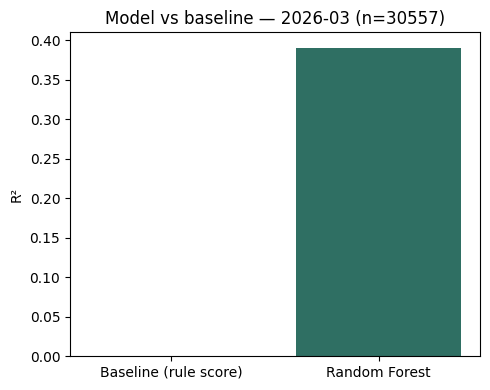

Artifacts this notebook produced for the paper:
- work/figures/model_vs_baseline.png
- work/outputs/model_vs_baseline_metrics.json
- work/outputs/top20_recommendations.json


In [25]:
os.makedirs("work/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(results["model"], results["R2"], color=["#B96A24", "#2F6F63"])
ax.set_ylabel("R²"); ax.set_title(f"Model vs baseline — {MONTH} (n={len(test_df)})")
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()

results.to_json("work/outputs/model_vs_baseline_metrics.json", orient="records", indent=2)

print("Artifacts this notebook produced for the paper:")
print("- work/figures/model_vs_baseline.png")
print("- work/outputs/model_vs_baseline_metrics.json")
print("- work/outputs/top20_recommendations.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
